In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_main = pd.read_csv('TSLA.csv')

In [4]:
df_main.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [5]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [6]:
df_main.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [7]:
df_main.shape

(2416, 7)

In [8]:
df_main.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [9]:
df_main.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [10]:
df_main.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Open,2416.0,1.862711e+02,1.187402e+02,16.139999,3.434250e+01,2.130350e+02,2.664500e+02,6.736900e+02
High,2416.0,1.895782e+02,1.208923e+02,16.629999,3.489750e+01,2.167450e+02,2.709275e+02,7.861400e+02
Low,2416.0,1.829166e+02,1.168576e+02,14.980000,3.358750e+01,2.088700e+02,2.621025e+02,6.735200e+02
Close,2416.0,1.864037e+02,1.191360e+02,15.800000,3.440000e+01,2.129600e+02,2.667750e+02,7.800000e+02
Adj Close,2416.0,1.864037e+02,1.191360e+02,15.800000,3.440000e+01,2.129600e+02,2.667750e+02,7.800000e+02
Volume,2416.0,5.572722e+06,4.987809e+06,118500.000000,1.899275e+06,4.578400e+06,7.361150e+06,4.706500e+07


In [11]:
df_main.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [12]:
df_main.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [13]:
df_main.duplicated().sum()

np.int64(0)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


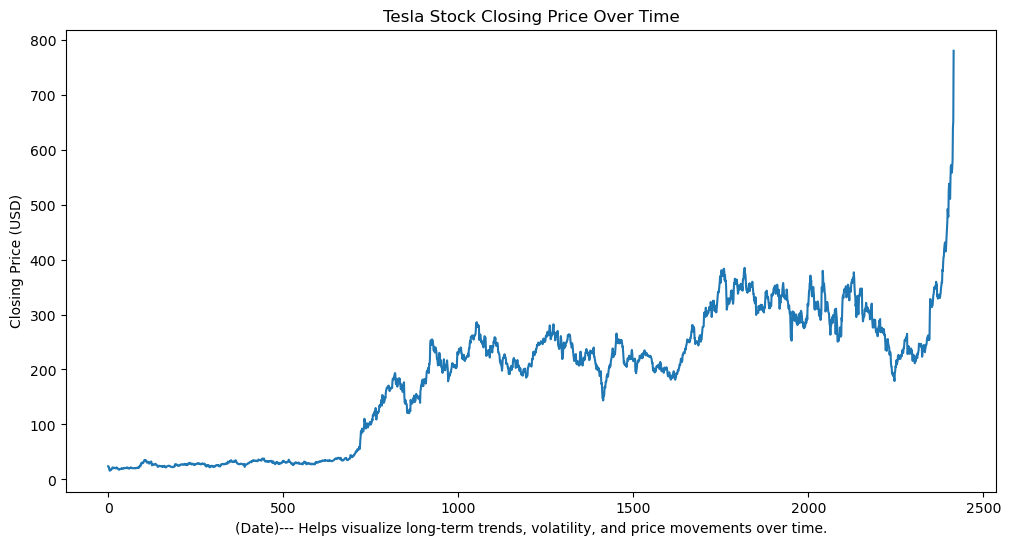

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df_main.index, df_main['Close'])
plt.title("Tesla Stock Closing Price Over Time")
plt.xlabel("(Date)--- Helps visualize long-term trends, volatility, and price movements over time.")
plt.ylabel("Closing Price (USD)")
plt.show()


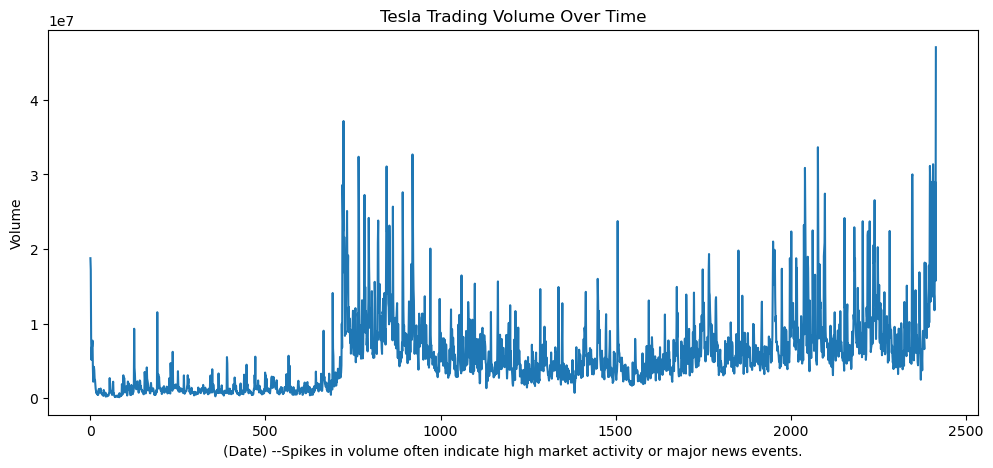

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df_main.index, df_main['Volume'])
plt.title("Tesla Trading Volume Over Time")
plt.xlabel("(Date) --Spikes in volume often indicate high market activity or major news events.")
plt.ylabel("Volume")
plt.show()


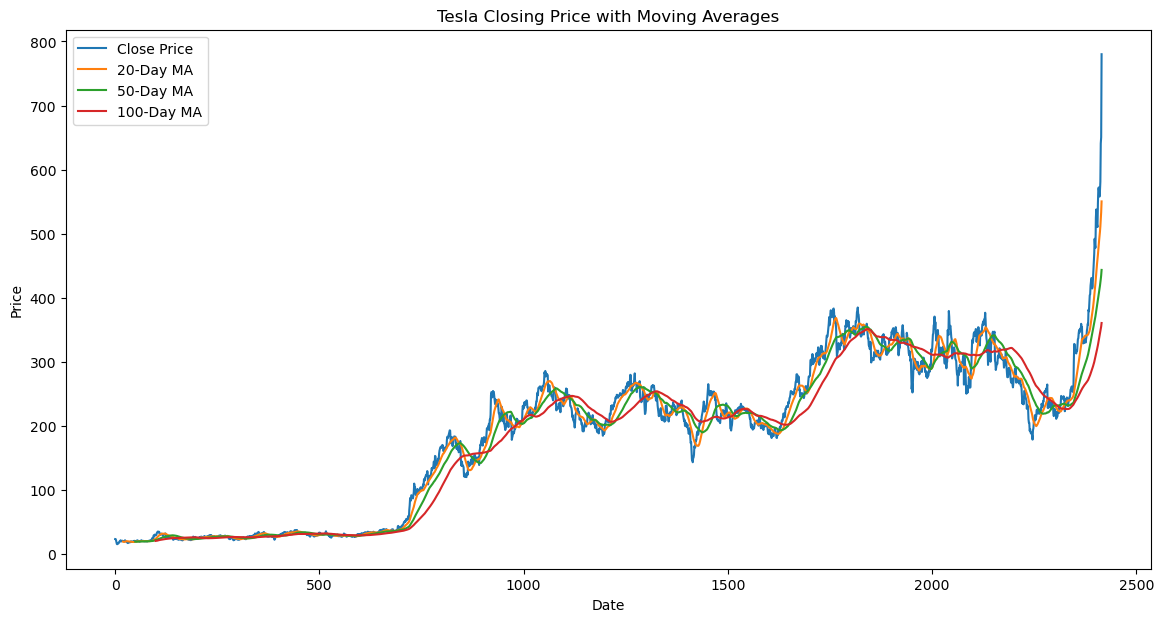

In [17]:
# Calculate moving averages
df_main['MA_20'] = df_main['Close'].rolling(window=20).mean()
df_main['MA_50'] = df_main['Close'].rolling(window=50).mean()
df_main['MA_100'] = df_main['Close'].rolling(window=100).mean()

# Plot Closing Price with Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(df_main.index, df_main['Close'], label='Close Price')
plt.plot(df_main.index, df_main['MA_20'], label='20-Day MA')
plt.plot(df_main.index, df_main['MA_50'], label='50-Day MA')
plt.plot(df_main.index, df_main['MA_100'], label='100-Day MA')

plt.title("Tesla Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


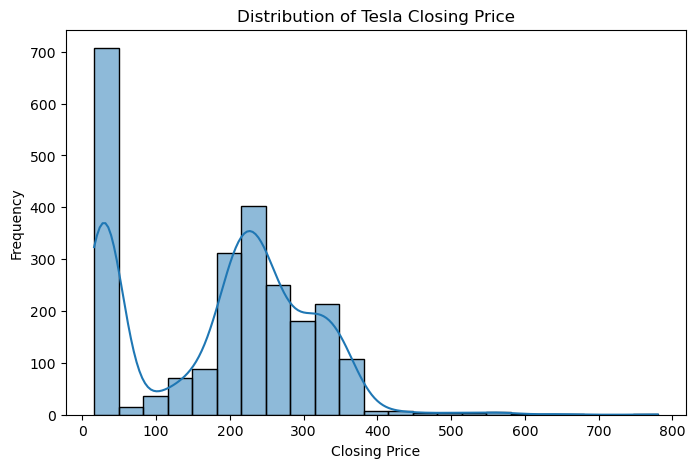

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['Close'], kde=True)
plt.title("Distribution of Tesla Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()


In [19]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Select only the Close price
close_data = df_main[['Close']]

In [20]:
# Define train size (80%)
train_size = int(len(close_data) * 0.8)

train_data = close_data[:train_size]
test_data = close_data[train_size:]


In [21]:
# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data
train_scaled = scaler.fit_transform(train_data)

# Transform test data
test_scaled = scaler.transform(test_data)


In [22]:
train_scaled[:5], test_scaled[:5]

(array([[0.02191224],
        [0.02174973],
        [0.01668472],
        [0.0092091 ],
        [0.00083966]]),
 array([[0.86489706],
        [0.86010294],
        [0.84615388],
        [0.85725891],
        [0.84859157]]))

In [23]:
import numpy as np

def create_sequences(data, time_steps=60, forecast_horizon=1):
    X, y = [], []
    
    for i in range(len(data) - time_steps - forecast_horizon + 1):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps : i + time_steps + forecast_horizon])
    
    return np.array(X), np.array(y)


In [24]:
TIME_STEPS = 60

X_train_1d, y_train_1d = create_sequences(train_scaled, TIME_STEPS, forecast_horizon=1)
X_test_1d, y_test_1d = create_sequences(test_scaled, TIME_STEPS, forecast_horizon=1)

print(X_train_1d.shape, y_train_1d.shape)
print(X_test_1d.shape, y_test_1d.shape)


(1872, 60, 1) (1872, 1, 1)
(424, 60, 1) (424, 1, 1)


In [25]:
X_train_5d, y_train_5d = create_sequences(train_scaled, TIME_STEPS, forecast_horizon=5)
X_test_5d, y_test_5d = create_sequences(test_scaled, TIME_STEPS, forecast_horizon=5)


In [26]:
X_train_10d, y_train_10d = create_sequences(train_scaled, TIME_STEPS, forecast_horizon=10)
X_test_10d, y_test_10d = create_sequences(test_scaled, TIME_STEPS, forecast_horizon=10)


In [27]:
# Shape → (samples, time_steps, features)
print("Before reshape:", X_train_1d.shape)

# Already correct shape because we used single feature
# But this line ensures clarity
X_train_1d = X_train_1d.reshape((X_train_1d.shape[0], X_train_1d.shape[1], 1))
X_test_1d  = X_test_1d.reshape((X_test_1d.shape[0],  X_test_1d.shape[1], 1))


Before reshape: (1872, 60, 1)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


In [29]:
def build_simple_rnn(input_shape, output_size):
    model = Sequential()
    
    model.add(SimpleRNN(50, activation='tanh', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(output_size))
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error'
    )
    
    return model


In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "simple_rnn_1day.h5",
    monitor='val_loss',
    save_best_only=True
)


In [31]:
simple_rnn_1d = build_simple_rnn(
    input_shape=(X_train_1d.shape[1], 1),
    output_size=1
)

history_rnn_1d = simple_rnn_1d.fit(
    X_train_1d, y_train_1d,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


c:\Users\srinu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1215

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0553 - val_loss: 0.0257
Epoch 2/30
48/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0093 - val_loss: 0.0161
Epoch 3/30
50/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0059 - val_loss: 0.0132
Epoch 4/30
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0040 - val_loss: 0.0125
Epoch 5/30
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0065
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0122
Epoch 7/30
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026 - val_loss: 0.0045
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027 - val_loss: 0.0067
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0039
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 0.0061
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - val_loss: 0.0031


In [32]:
simple_rnn_1d.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,955 (31.08 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,304 (20.72 KB)

In [39]:
# Predict
rnn_predictions_1d = simple_rnn_1d.predict(X_test_1d)

# Inverse scale predictions
rnn_predictions_1d = scaler.inverse_transform(rnn_predictions_1d)

# Reshape actual values to 2D
y_test_1d_reshaped = y_test_1d.reshape(-1, 1)

# Inverse scale actual values
y_test_1d_actual = scaler.inverse_transform(y_test_1d_reshaped)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [40]:
from sklearn.metrics import mean_squared_error

rnn_mse_1d = mean_squared_error(y_test_1d_actual, rnn_predictions_1d)
print("SimpleRNN 1-Day Prediction MSE:", rnn_mse_1d)


SimpleRNN 1-Day Prediction MSE: 1145.3733675260899


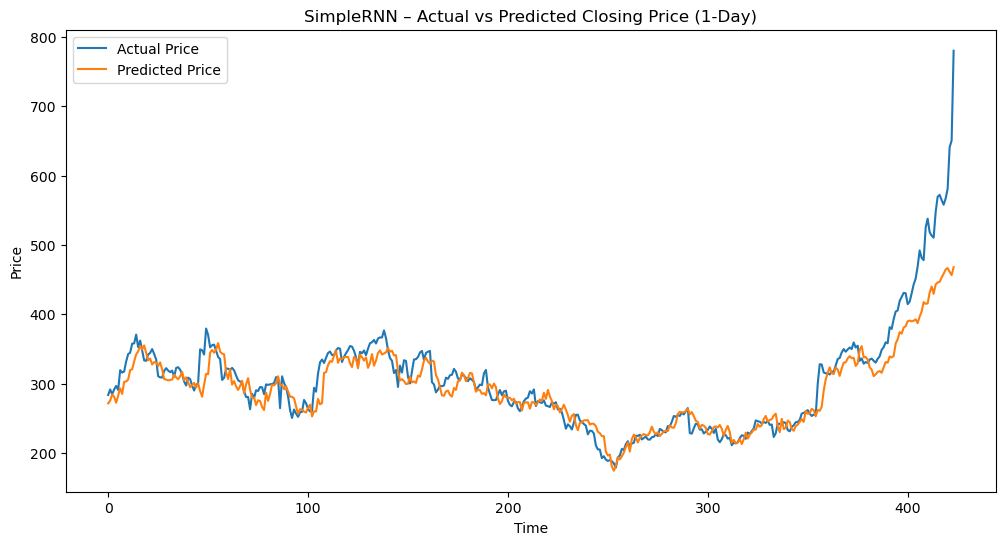

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_1d_actual, label="Actual Price")
plt.plot(rnn_predictions_1d, label="Predicted Price")
plt.title("SimpleRNN – Actual vs Predicted Closing Price (1-Day)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


## LSTM code


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


In [43]:
def build_lstm_model(input_shape, output_size):
    model = Sequential()
    
    model.add(LSTM(50, return_sequences=False, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(output_size))
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error'
    )
    
    return model


In [44]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "lstm_1day.h5",
    monitor='val_loss',
    save_best_only=True
)


In [45]:
lstm_1d = build_lstm_model(
    input_shape=(X_train_1d.shape[1], 1),
    output_size=1
)

history_lstm_1d = lstm_1d.fit(
    X_train_1d, y_train_1d,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/30


c:\Users\srinu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0257

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0110 - val_loss: 0.0034
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0026

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 3/30
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0022

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 4/30
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0022

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0014 - val_loss: 0.0024


In [46]:
lstm_1d.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [47]:
# Predict on test data
lstm_predictions_1d = lstm_1d.predict(X_test_1d)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [48]:
# Inverse scale predictions
lstm_predictions_1d = scaler.inverse_transform(lstm_predictions_1d)

# Reshape actual values from 3D → 2D
y_test_1d_reshaped = y_test_1d.reshape(-1, 1)

# Inverse scale actual values
y_test_1d_actual = scaler.inverse_transform(y_test_1d_reshaped)


In [50]:
from sklearn.metrics import mean_squared_error

lstm_mse_1d = mean_squared_error(y_test_1d_actual, lstm_predictions_1d)
print("LSTM 1-Day Prediction MSE:", lstm_mse_1d)


LSTM 1-Day Prediction MSE: 519.7097545890346


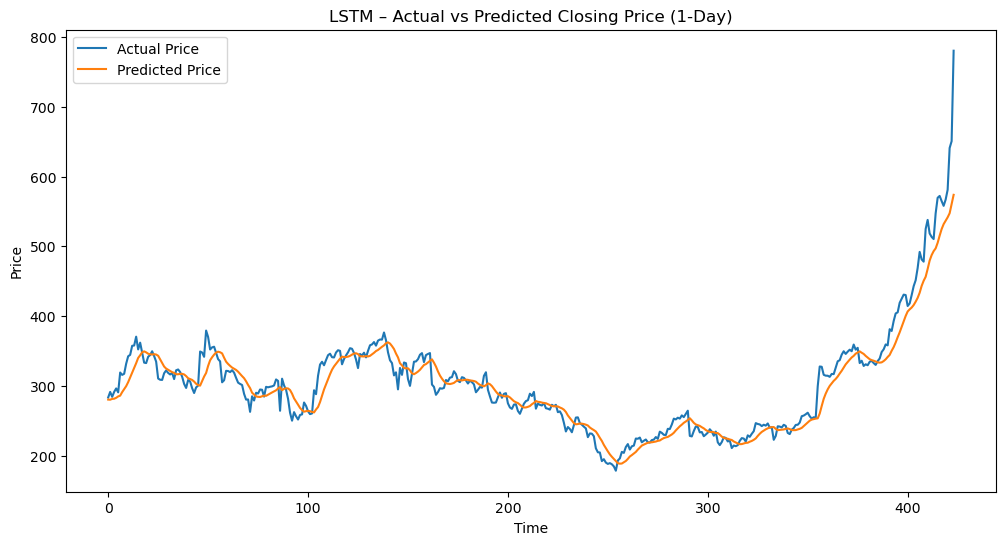

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_1d_actual, label="Actual Price")
plt.plot(lstm_predictions_1d, label="Predicted Price")
plt.title("LSTM – Actual vs Predicted Closing Price (1-Day)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [51]:
lstm_5d = build_lstm_model(
    input_shape=(X_train_5d.shape[1], 1),
    output_size=5
)


c:\Users\srinu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
history_lstm_5d = lstm_5d.fit(
    X_train_5d, y_train_5d,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0467 - val_loss: 0.0146
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0066 - val_loss: 0.0049
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0045 - val_loss: 0.0083
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0041 - val_loss: 0.0078


In [53]:
# Predict
lstm_predictions_5d = lstm_5d.predict(X_test_5d)

# Reshape for inverse scaling
lstm_predictions_5d_reshaped = lstm_predictions_5d.reshape(-1, 1)
y_test_5d_reshaped = y_test_5d.reshape(-1, 1)

# Inverse transform
lstm_predictions_5d_actual = scaler.inverse_transform(lstm_predictions_5d_reshaped)
y_test_5d_actual = scaler.inverse_transform(y_test_5d_reshaped)

# MSE
lstm_mse_5d = mean_squared_error(y_test_5d_actual, lstm_predictions_5d_actual)
print("LSTM 5-Day Prediction MSE:", lstm_mse_5d)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
LSTM 5-Day Prediction MSE: 3054.755526159391


In [54]:
lstm_10d = build_lstm_model(
    input_shape=(X_train_10d.shape[1], 1),
    output_size=10
)


c:\Users\srinu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
history_lstm_10d = lstm_10d.fit(
    X_train_10d, y_train_10d,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0573 - val_loss: 0.0101
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0095 - val_loss: 0.0068
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0069 - val_loss: 0.0043
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0048 - val_loss: 0.0068


In [56]:
# Predict
lstm_predictions_10d = lstm_10d.predict(X_test_10d)

# Reshape
lstm_predictions_10d_reshaped = lstm_predictions_10d.reshape(-1, 1)
y_test_10d_reshaped = y_test_10d.reshape(-1, 1)

# Inverse transform
lstm_predictions_10d_actual = scaler.inverse_transform(lstm_predictions_10d_reshaped)
y_test_10d_actual = scaler.inverse_transform(y_test_10d_reshaped)

# MSE
lstm_mse_10d = mean_squared_error(y_test_10d_actual, lstm_predictions_10d_actual)
print("LSTM 10-Day Prediction MSE:", lstm_mse_10d)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
LSTM 10-Day Prediction MSE: 2512.278779164103


In [57]:
lstm_1d.save("lstm_1day.h5")
lstm_5d.save("lstm_5day.h5")
lstm_10d.save("lstm_10day.h5")